In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
path="/content/drive/MyDrive/Colab Notebooks/04_PythonForFinance/Dataset/SCOTIA1.csv"
scotia1_df = pd.read_csv(path)

In [24]:
scotia1_df.head()

,Mes,Titulos Mes Anterior,Titulos Mes Actual,Num Emisora,Emisora,Serie,Costo Unitario,Precio Inicial,Precio Final,Diferencial,Valor de Mercado,Plusvalia o Minusvalia,Tendencia Accionaria
0,may-25,633622,634148,51,SCOTIA1,CU1,2.330966,2.452896,2.466497,0.013601,1564124.14,85946.82,NaN
1,abr-25,453525,633622,51,SCOTIA1,CU1,2.330860,2.438961,2.452896,0.013935,1554208.87,77324.63,NaN
2,mar-25,423028,453525,51,SCOTIA1,CU1,2.286293,2.423415,2.438961,0.015546,1106129.79,69238.66,NaN
3,feb-25,307241,423028,51,SCOTIA1,CU1,2.275417,2.408701,2.423415,0.014714,1025172.40,62607.45,NaN
4,ene-25,307241,307241,51,SCOTIA1,CU1,2.221602,2.391975,2.408701,0.016726,740051.70,57484.49,NaN


In [25]:
df_f = scotia1_df["Valor de Mercado"]
df_f

,Valor de Mercado
0,1564124.14
1,1554208.87
2,1106129.79
3,1025172.40
4,740051.70
5,704337.09
6,709815.81
7,714919.70
8,720317.00
9,724854.03


In [26]:
scotia1_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Mes                     12 non-null     object 
 1   Titulos Mes Anterior    12 non-null     int64  
 2   Titulos Mes Actual      12 non-null     int64  
 3   Num Emisora             12 non-null     int64  
 4   Emisora                 12 non-null     object 
 5   Serie                   12 non-null     object 
 6   Costo Unitario          12 non-null     float64
 7   Precio Inicial          12 non-null     float64
 8   Precio Final            12 non-null     float64
 9   Diferencial             12 non-null     float64
 10  Valor de Mercado        12 non-null     float64
 11  Plusvalia o Minusvalia  12 non-null     float64
 12  Tendencia Accionaria    4 non-null      float64
dtypes: float64(7), int64(3), object(3)
memory usage: 1.3+ KB


Simple Rate of Return

${P_1-P_0 \over P_0} = {P_1 \over P_0} -1$

In [27]:
scotia1_df['Simple_return'] = (scotia1_df['Precio Final'] / scotia1_df['Precio Final'].shift(1)) - 1
#scotia1_df['Simple_return'] = (scotia1_df['Titulos Mes Anterior'] / scotia1_df['Titulos Mes Anterior'].shift(1)) - 1
print (scotia1_df['Simple_return'])

0          NaN
1    -0.005514
2    -0.005681
3    -0.006374
4    -0.006072
5    -0.048260
6     0.007779
7     0.007190
8     0.007550
9     0.006299
10    0.006918
11    0.006911
Name: Simple_return, dtype: float64


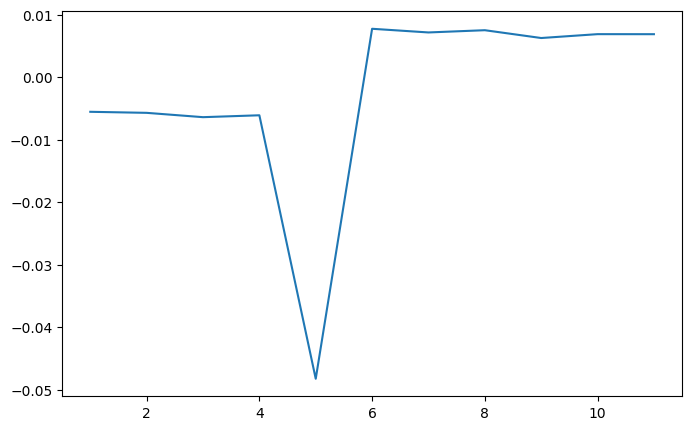

In [29]:
scotia1_df['Simple_return'].plot(figsize=(8,5))
plt.show()

In [32]:
tickers = ['Q', 'SCOTDVC', 'SCOT-FR', 'SCOTGL', 'SCOTIA1', 'SCOT-RV', 'SCOTUSA']

#path="/content/drive/MyDrive/Colab Notebooks/04_PythonForFinance/Dataset/SCOTIA1.csv"
#scotia1_df = pd.read_csv(path)

new_data = pd.DataFrame()
path="/content/drive/MyDrive/Colab Notebooks/04_PythonForFinance/Dataset/" + tickers[0] + ".csv"
Q_data = pd.read_csv(path)
new_data = Q_data['Precio Final']

In [55]:
tickers = ['SCOTDVC', 'SCOT-FR', 'SCOTGL', 'SCOTIA1', 'SCOT-RV', 'SCOTUSA', 'Q']

new_data = pd.DataFrame()

for t in tickers:
  path="/content/drive/MyDrive/Colab Notebooks/04_PythonForFinance/Dataset/" + t + ".csv"
  new_data[t] = pd.read_csv(path)['Precio Final']

In [56]:
new_data

,SCOTDVC,SCOT-FR,SCOTGL,SCOTIA1,SCOT-RV,SCOTUSA,Q
0,2.037805,1.892320,9.521207,2.466497,3.375628,24.667489,209.82
1,2.024008,1.725810,9.226496,2.452896,3.131952,23.269826,216.10
2,2.015105,1.713701,9.588273,2.438961,3.028176,24.016227,177.83
3,1.993621,1.670522,9.983943,2.423415,3.015334,25.703151,NaN
4,1.967606,1.637020,10.446506,2.408701,2.985044,26.836575,NaN
5,1.867963,1.518639,8.733787,2.292458,2.912830,22.375090,NaN
6,1.885802,1.558266,8.969214,2.310290,2.907911,21.762569,NaN
7,1.899869,1.608674,9.688517,2.326902,2.928799,24.075382,NaN
8,1.928339,1.658239,9.932473,2.344469,2.976345,24.464433,NaN
9,1.924493,1.671792,9.938278,2.359236,2.887687,25.405753,NaN


In [7]:
path="/content/drive/MyDrive/Colab Notebooks/04_PythonForFinance/Dataset/SCOTDVC.csv"
df = pd.read_csv(path, usecols=['Mes', 'Precio Final'])
df

,Mes,Precio Final
0,may-25,2.037805
1,abr-25,2.024008
2,mar-25,2.015105
3,feb-25,1.993621
4,ene-25,1.967606
5,jun-24,1.867963
6,jul-24,1.885802
7,ago-24,1.899869
8,sep-24,1.928339
9,oct-24,1.924493


In [27]:
df = pd.read_csv(path, usecols=['Mes', 'Precio Final'], parse_dates=['Mes'])
df

/tmp/ipython-input-27-42198252.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(path, usecols=['Mes', 'Precio Final'], parse_dates=['Mes'])


,Mes,Precio Final
0,may-25,209.82
1,abr-25,216.10
2,mar-25,177.83


In [28]:
df.set_index('Mes', inplace=True)

# Obtener el precio final de todos los activos

**¿Qué hace este código?**
1. Usa ``usecols`` para solo leer _Mes_ y _Precio Final_.

2. Convierte la columna _Mes_ a formato datetime``(parse_dates=['Fecha'])``.

3. Establece la fecha como índice ``(set_index)``.

4. Renombra la columna de precios como el ticker correspondiente.

5. Usa ``join`` para ir agregando cada columna al DataFrame principal alineado por fecha.

6. Ordena por fecha al final para asegurar consistencia temporal.

In [58]:
tickers = ['SCOTDVC', 'SCOT-FR', 'SCOTGL', 'SCOTIA1','SCOT-LB', 'SCOT-RV', 'SCOTUSA', 'Q']

new_data = pd.DataFrame()

for t in tickers:
  path = "/content/drive/MyDrive/Colab Notebooks/04_PythonForFinance/Dataset/" + t + ".csv"
  df = pd.read_csv(path, usecols=['Mes', 'Precio Final'], parse_dates=['Mes'])
  df.set_index('Mes', inplace=True)
  df.rename(columns={'Precio Final': t}, inplace=True)

  # Unimos los datos al dataframe principal por fecha
  if new_data.empty:
    new_data = df
  else:
    new_data = new_data.join(df, how='outer')

# Opcional: ordena por fecha
new_data.sort_index(inplace=True)


In [59]:
print (new_data)

             SCOTDVC   SCOT-FR     SCOTGL   SCOTIA1   SCOT-LB   SCOT-RV  \
Mes                                                                       
2024-06-01  1.867963  1.518639   8.733787  2.292458  0.626070  2.912830   
2024-07-01  1.885802  1.558266   8.969214  2.310290  0.657369  2.907911   
2024-08-01  1.899869  1.608674   9.688517  2.326902  0.705676  2.928799   
2024-09-01  1.928339  1.658239   9.932473  2.344469  0.721017  2.976345   
2024-10-01  1.924493  1.671792   9.938278  2.359236  0.734899  2.887687   
2024-11-01  1.938746  1.610585  10.276987  2.375557  0.778594  2.825952   
2024-12-01  1.945413  1.539694  10.074264  2.391975  0.746704  2.814855   
2025-01-01  1.967606  1.637020  10.446506  2.408701  0.771177  2.985044   
2025-02-01  1.993621  1.670522   9.983943  2.423415  0.758720  3.015334   
2025-03-01  2.015105  1.713701   9.588273  2.438961  0.735902  3.028176   
2025-04-01  2.024008  1.725810   9.226496  2.452896  0.688993  3.131952   
2025-05-01  2.037805  1.8

In [60]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 16 entries, 2024-06-01 to NaT
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   SCOTDVC  12 non-null     float64
 1   SCOT-FR  12 non-null     float64
 2   SCOTGL   12 non-null     float64
 3   SCOTIA1  12 non-null     float64
 4   SCOT-LB  12 non-null     float64
 5   SCOT-RV  12 non-null     float64
 6   SCOTUSA  12 non-null     float64
 7   Q        3 non-null      float64
dtypes: float64(8)
memory usage: 1.1 KB


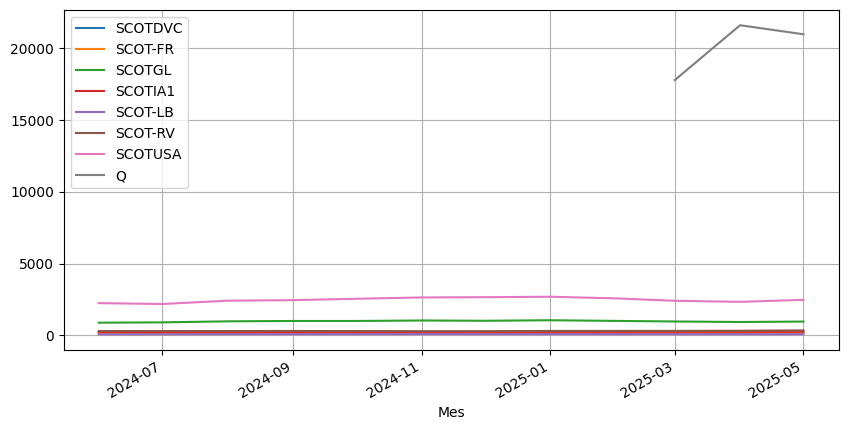

In [67]:
(new_data * 100).plot(figsize=(10,5), grid=True)
plt.show()

## Grafico de precio final

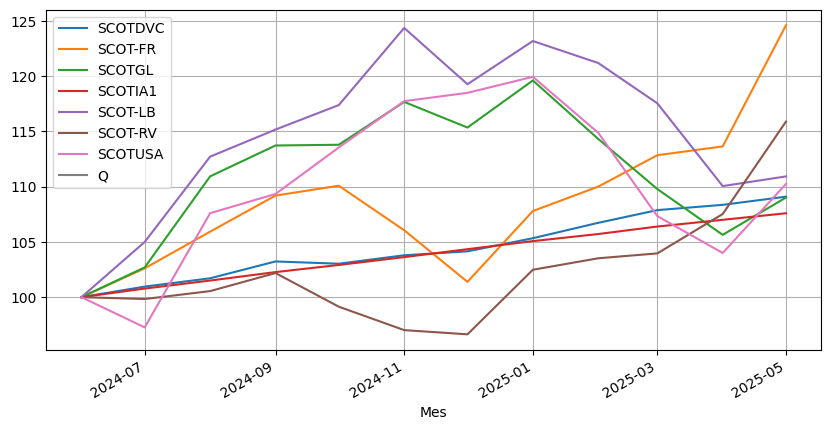

In [66]:
# Normalized Data to have a better comparison
(new_data / new_data.iloc[0] * 100).plot(figsize=(10,5), grid=True)
plt.show()

# Obtener valor de activos

In [3]:
import pandas as pd
from pandas_datareader import data as wb
import matplotlib.pyplot as plt

tickers = ['SCOTDVC', 'SCOT-FR', 'SCOTGL', 'SCOTIA1','SCOT-LB', 'SCOT-RV', 'SCOTUSA', 'Q']

valores_df = pd.DataFrame()

for t in tickers:
  path = "/content/drive/MyDrive/Colab Notebooks/04_PythonForFinance/Dataset/" + t + ".csv"
  df_2 = pd.read_csv(path, usecols=['Mes', 'Valor de Mercado'], parse_dates=['Mes'])
  df_2.set_index('Mes', inplace=True)
  df_2.rename(columns={'Valor de Mercado': t}, inplace=True)

  # Unimos los datos al dataframe principal por fecha
  if valores_df.empty:
    valores_df = df_2
  else:
    valores_df = valores_df.join(df_2, how='outer')

# Opcional: ordena por fecha
valores_df.sort_index(inplace=True)

In [72]:
print (valores_df)

               SCOTDVC    SCOT-FR     SCOTGL     SCOTIA1    SCOT-LB  \
Mes                                                                   
2024-06-01  1271004.99  128962.82  161548.86   704337.09  170463.84   
2024-07-01  1283143.05  132327.95  165903.55   709815.81  178985.80   
2024-08-01  1292714.56  136608.60  179208.50   714919.70  192138.64   
2024-09-01  1312086.21  140817.66  183720.95   720317.00  196315.62   
2024-10-01  1309469.30  141968.58  183828.33   724854.03  200095.36   
2024-11-01  1319167.37  136770.88  190093.43   729868.51  211992.46   
2024-12-01  1323703.75  130750.81  186343.66   734912.79  203309.58   
2025-01-01  1338804.38  139015.74  193229.02   740051.70  209972.99   
2025-02-01  1356505.58  141860.73  184672.99  1025172.40  206581.25   
2025-03-01  1371123.79  145527.49  177354.29  1106129.79  200368.45   
2025-04-01  1377181.60  146555.79  170662.50  1554208.87  187596.26   
2025-05-01  1386569.39  160695.81  176113.77  1564124.14  189090.24   
NaT   

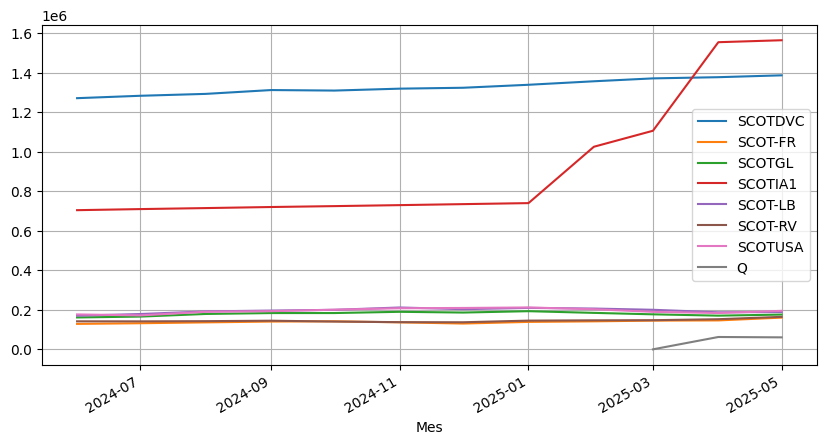

In [80]:
# Normalized Data to have a better comparison
#(valores_df / valores_df.iloc[0]).plot(figsize=(10,5), grid=True)
valores_df.plot(figsize=(10,5), grid=True)

plt.show()

# Obtener retorno de inversion del portafolio

In [64]:
import pandas as pd
from pandas_datareader import data as wb
import matplotlib.pyplot as plt

tickers = ['SCOTDVC', 'SCOT-FR', 'SCOTGL', 'SCOTIA1','SCOT-LB', 'SCOT-RV', 'SCOTUSA', 'Q']

new_data = pd.DataFrame()

for t in tickers:
  path = "/content/drive/MyDrive/Colab Notebooks/04_PythonForFinance/Dataset/" + t + ".csv"
  df = pd.read_csv(path, usecols=['Mes', 'Precio Final'], parse_dates=['Mes'])
  df.set_index('Mes', inplace=True)
  df.rename(columns={'Precio Final': t}, inplace=True)

  # Unimos los datos al dataframe principal por fecha
  if new_data.empty:
    new_data = df
  else:
    new_data = new_data.join(df, how='outer')

# Opcional: ordena por fecha
new_data.sort_index(inplace=True)

# Calculo de riesgo del portafolio

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
# obtain the values of the last valid row
valores_df.iloc[-5]

,2025-05-01
SCOTDVC,1386569.39
SCOT-FR,160695.81
SCOTGL,176113.77
SCOTIA1,1564124.14
SCOT-LB,189090.24
SCOT-RV,164565.24
SCOTUSA,194971.83
Q,60847.80


In [22]:
# Obtain the weigth of the assets

total = 3896978
weights = valores_df.iloc[-5] / total

print (weights)
print (weights.sum())

SCOTDVC    0.355806
SCOT-FR    0.041236
SCOTGL     0.045192
SCOTIA1    0.401368
SCOT-LB    0.048522
SCOT-RV    0.042229
SCOTUSA    0.050032
Q          0.015614
Name: 2025-05-01 00:00:00, dtype: float64
1.000000056454001


In [38]:
weights

,2025-05-01
SCOTDVC,0.355806
SCOT-FR,0.041236
SCOTGL,0.045192
SCOTIA1,0.401368
SCOT-LB,0.048522
SCOT-RV,0.042229
SCOTUSA,0.050032
Q,0.015614


In [42]:
weights.sort_values(ascending=True)

,2025-05-01
Q,0.015614
SCOT-FR,0.041236
SCOT-RV,0.042229
SCOTGL,0.045192
SCOT-LB,0.048522
SCOTUSA,0.050032
SCOTDVC,0.355806
SCOTIA1,0.401368


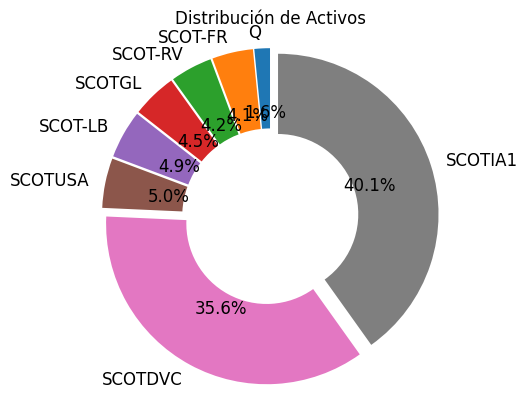

In [51]:
# Pie Chart
#plt.pie(weights['Valor'], labels=weights['Activos'], autopct='%1.1f%%')

df_ordenado = weights.sort_values(ascending=True)

# Crear un explode automático (ligera separación de cada trozo)
explode = [0.05] * len(df_ordenado)

plt.pie(df_ordenado,
        labels=df_ordenado.index,
        autopct='%1.1f%%',
        explode=explode,
        startangle=90,
        textprops={'fontsize': 12},
        wedgeprops={'width': 0.5}
        )
plt.title('Distribución de Activos')
plt.axis('equal')
plt.show()

In [28]:
# Portfolio variance
pfolio_var = np.dot(weights.T, np.dot(valores_df.cov() * 250, weights))
print ("Portfolio variance: " + str(round(pfolio_var, 4)))

# Portfolio volatility
pfolio_vol = np.dot(weights.T, np.dot(valores_df.cov() * 250, weights)) ** 0.5
print ("Portfolio variance: " + str(round(pfolio_var, 4)))

print (str(round(pfolio_var, 5) * 100) + ' %')

Portfolio variance: 5163624800836.84
Portfolio variance: 5163624800836.84
516362480083684.0 %
